# Power scan — full intensity-fluctuation model

Everything is saved under `results/<date>/<TITLE>/`. Plots use the interactive **ipympl**
backend: drag to zoom, home button to reset.

In [1]:
TITLE    = "Jun23_powerscan_P1"   # results/<date>/<TITLE>/ ...
DAY      = "Jun23"
MATERIAL = "CdTe110"               # bare sample name (config goes in CONFIG)

CONFIG = {                          # optical configuration, saved into every pkl
    "P1": True, "P3": False,
    "filters": {"H3": "700-40", "H5": "425-25"},
    "filter_layout": "per-channel",
}

# --- the power scan: one acquisition per (power, stage angle) ---
#   angle_deg moves the half-wave plate (set to None to set the power by hand).
POWER_POINTS = [
    {"power_mw": 10.0,  "angle_deg": None},
    {"power_mw": 25.0,  "angle_deg": None},
    {"power_mw": 50.0,  "angle_deg": None},
    {"power_mw": 80.0,  "angle_deg": None},
]
CHUNK_MINUTES = 2.0
MAX_CHUNKS    = 3

DO_DENSE_SCAN   = True
DENSE_ANGLES    = list(range(0, 91, 3))
DENSE_SECONDS   = 3.0
MALUS = {"p_max": 100.0, "theta0": 0.0, "offset": 0.0}

# --- analysis ---
HARMONICS  = (3, 5)        # H4 is usually a dark/degenerate channel here
TAU_IN_NS  = 4.0
G2_METHOD  = "delay"       # 'delay' | 'direct' | 'heralded'
K_POLY_DEG = 3             # smoothing degree of the dense log-log K(n) fit

# --- time tagger ---
CHANNELS        = [1, 2, 3, 4, 5, 6]
MODE_ON_CHANNEL = ["H3T", "H3R", "H4T", "H4R", "H5T", "H5R"]
DELAYS_PS       = [0, 0, 0, 0, 0, 0]
TRIGGER_V       = 0.5
BINWIDTH_PS     = 100
NUM_BINS        = 50000
COINC_WINDOW_PS = 25000
REP_RATE_HZ     = 18.66e6
WAVELENGTH_NM   = 2100

LIVE_HARDWARE = False
PRM1_SERIAL   = "27264707"   # half-wave-plate stage


In [2]:
%matplotlib widget
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "core.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATA_DIR    = ROOT / "data" / DAY / TITLE
DENSE_DIR   = ROOT / "data" / DAY / f"{TITLE}_intensity"
RESULTS_DIR = ROOT / "results"
print("Project root:", ROOT)
print("Scan ->", DATA_DIR)

Project root: /Users/simon.wtmn/Desktop/Quantum_SHHG
Scan -> /Users/simon.wtmn/Desktop/Quantum_SHHG/data/Jun23/Jun23_powerscan_P1


## 1. Acquire the power scan

In [3]:
from src.acquisition import (Acquisition, AcquisitionConfig, LaserParams,
                             TimeTaggerParams, ChunkingParams, ScanPoint)
from src.measurement import CombinedRecorder, CountrateRecorder
from src.hardware import RotationStageController

SCAN_PATH = None
DENSE_PATH = None

def _tt():
    return TimeTaggerParams(channels=CHANNELS, mode_on_channel=MODE_ON_CHANNEL,
                            trigger_levels_v=TRIGGER_V, delays_ps=DELAYS_PS,
                            binwidth_ps=BINWIDTH_PS, num_bins=NUM_BINS,
                            coincidence_window_ps=COINC_WINDOW_PS)

if LIVE_HARDWARE:
    cfg = AcquisitionConfig(
        base_dir=DATA_DIR, material=MATERIAL, experiment_type="g2_heralded_virtual",
        configuration=CONFIG, laser=LaserParams(rep_rate_hz=REP_RATE_HZ, wavelength_nm=WAVELENGTH_NM),
        timetagging=_tt(),
        chunking=ChunkingParams(enabled=True, chunk_minutes=CHUNK_MINUTES,
                                max_chunks=MAX_CHUNKS, stop_when_reached=False))
    stages = RotationStageController([PRM1_SERIAL]) if any(p["angle_deg"] is not None for p in POWER_POINTS) else None
    with Acquisition(cfg, recorder=CombinedRecorder(), stages=stages) as acq:
        points = [ScanPoint(power_mw=p["power_mw"], angle_deg=p["angle_deg"],
                            stage_id=(PRM1_SERIAL if p["angle_deg"] is not None else None),
                            label=f'{p["power_mw"]:g}mW') for p in POWER_POINTS]
        acq.run_scan(points)
        SCAN_PATH = acq.save_dir
    print("Power scan ->", SCAN_PATH)
else:
    print("[offline] LIVE_HARDWARE is False — set SCAN_PATH below to analyse existing data.")

[offline] LIVE_HARDWARE is False — set SCAN_PATH below to analyse existing data.


## 1bis. Dense intensity scan (optional)

Count-rate-only sweep of the half-wave-plate angle. Cheap, and gives many extra points for a
smooth $K(n)$. Power per angle is recovered from Malus' law (`MALUS`).

In [4]:
if LIVE_HARDWARE and DO_DENSE_SCAN:
    cfg_d = AcquisitionConfig(
        base_dir=DENSE_DIR, material=MATERIAL, experiment_type="intensity_scan",
        configuration=CONFIG, laser=LaserParams(rep_rate_hz=REP_RATE_HZ, wavelength_nm=WAVELENGTH_NM),
        timetagging=_tt())
    stages = RotationStageController([PRM1_SERIAL])
    with Acquisition(cfg_d, recorder=CountrateRecorder(), stages=stages) as acq:
        for th in DENSE_ANGLES:
            acq.run_point(ScanPoint(angle_deg=th, stage_id=PRM1_SERIAL, label=f"ang_{th:g}"),
                          duration_s=DENSE_SECONDS)
        DENSE_PATH = acq.save_dir
    print("Dense intensity scan ->", DENSE_PATH)
else:
    print("[offline or disabled] dense scan skipped.")

[offline or disabled] dense scan skipped.


In [5]:
# --- offline fallback: point at existing data (edit these paths) ---
if SCAN_PATH is None:
    SCAN_PATH = ROOT / "data" / "Jun16" / "PowerScan_GaAs100_P1"
print("Analysing scan:", SCAN_PATH)
print("Dense K(n) from:", DENSE_PATH)

Analysing scan: /Users/simon.wtmn/Desktop/Quantum_SHHG/data/Jun16/PowerScan_GaAs100_P1
Dense K(n) from: None


## 2. Full model + save

Builds and saves the four model plots + a 2x2 dashboard under `results/<date>/<TITLE>/model/`.
Pass `intensity_runs=DENSE_PATH` + `malus=MALUS` to use the dense $K(n)$.

AnalysisReport 'Jun23_powerscan_P1': 6 run(s) (comparison), source=physical
  -> results: /Users/simon.wtmn/Desktop/Quantum_SHHG/results/2026-06-16/Jun23_powerscan_P1
PowerScanReport 'Jun23_powerscan_P1': 6 powers (10.056-94.882 mW)
  -> results: /Users/simon.wtmn/Desktop/Quantum_SHHG/results/2026-06-16/Jun23_powerscan_P1
   P(mW)         I3         I5     K3     K5   g2_33   g2_55  (g-1)/K2_3  (g-1)/K2_5
------------------------------------------------------------------------------------
    10.1  1.018e+04      456.1   2.69   4.76   1.141   2.000      0.0194      0.0441
    21.8  8.129e+04  1.798e+04   2.85   4.29   1.212   1.336      0.0262      0.0182
    36.9  3.866e+05  1.464e+05   2.80   3.29   1.197   1.304      0.0252      0.0281
    53.3  1.039e+06   4.12e+05   2.47   2.40   1.188   1.276      0.0308      0.0478
    82.0  2.687e+06  9.412e+05   2.02   1.75   1.169   1.250      0.0414      0.0822
    94.9  3.574e+06  1.204e+06   1.95   1.69   1.165   1.244      0.0431      0.0

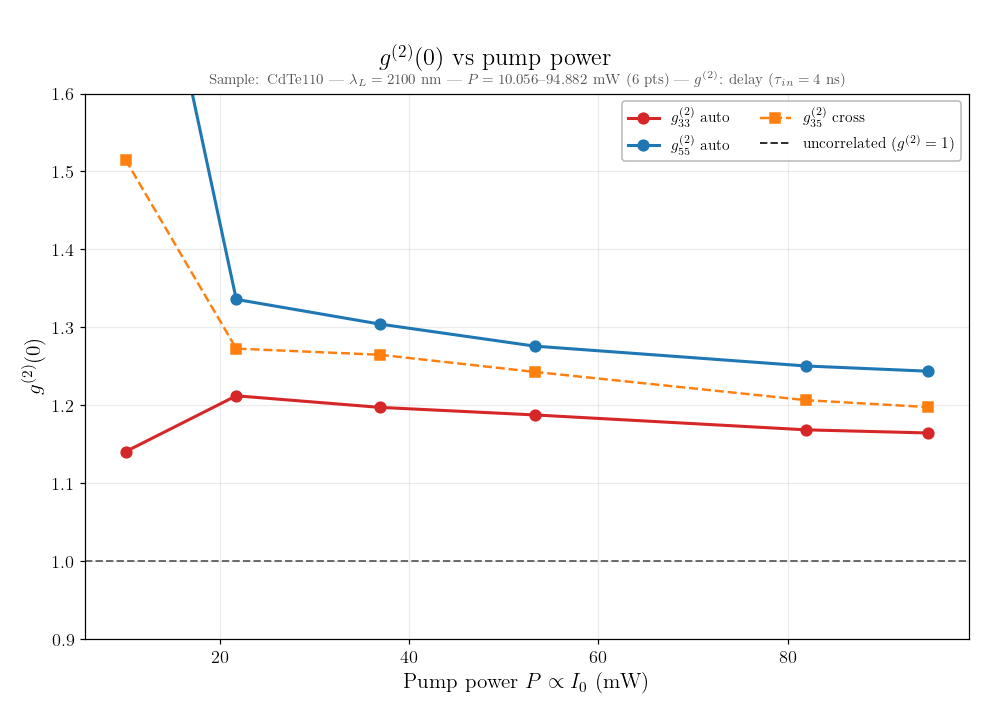

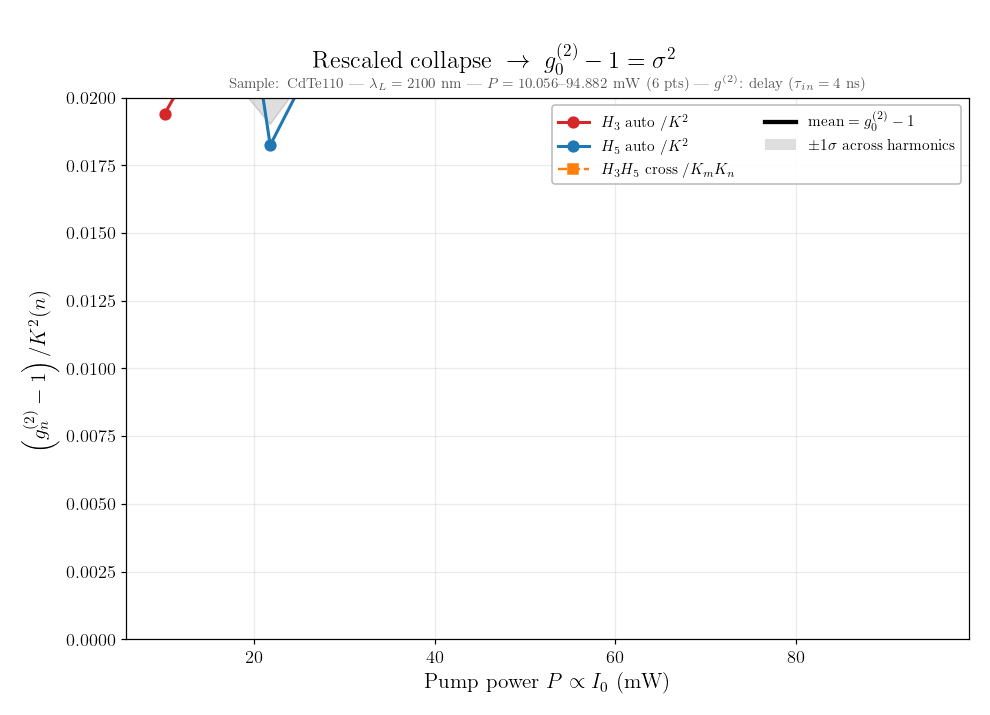

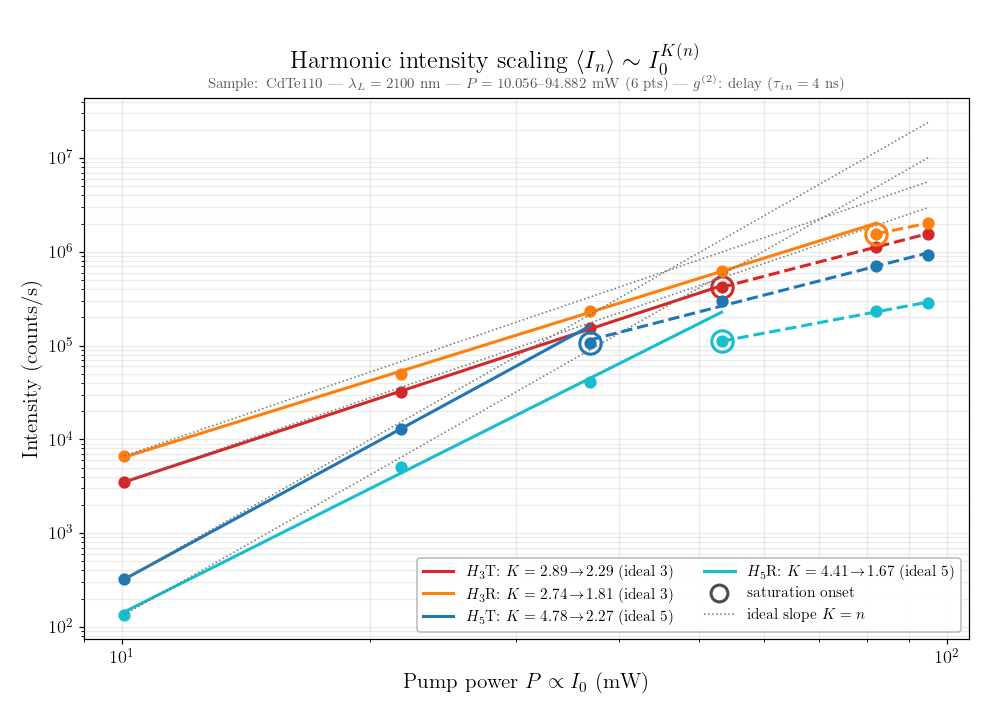

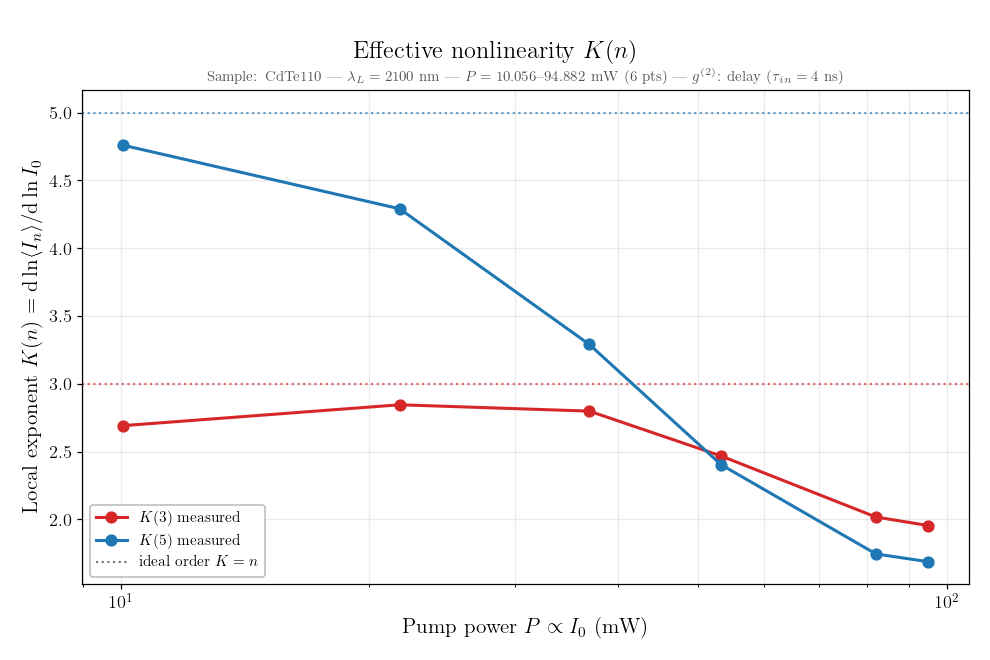

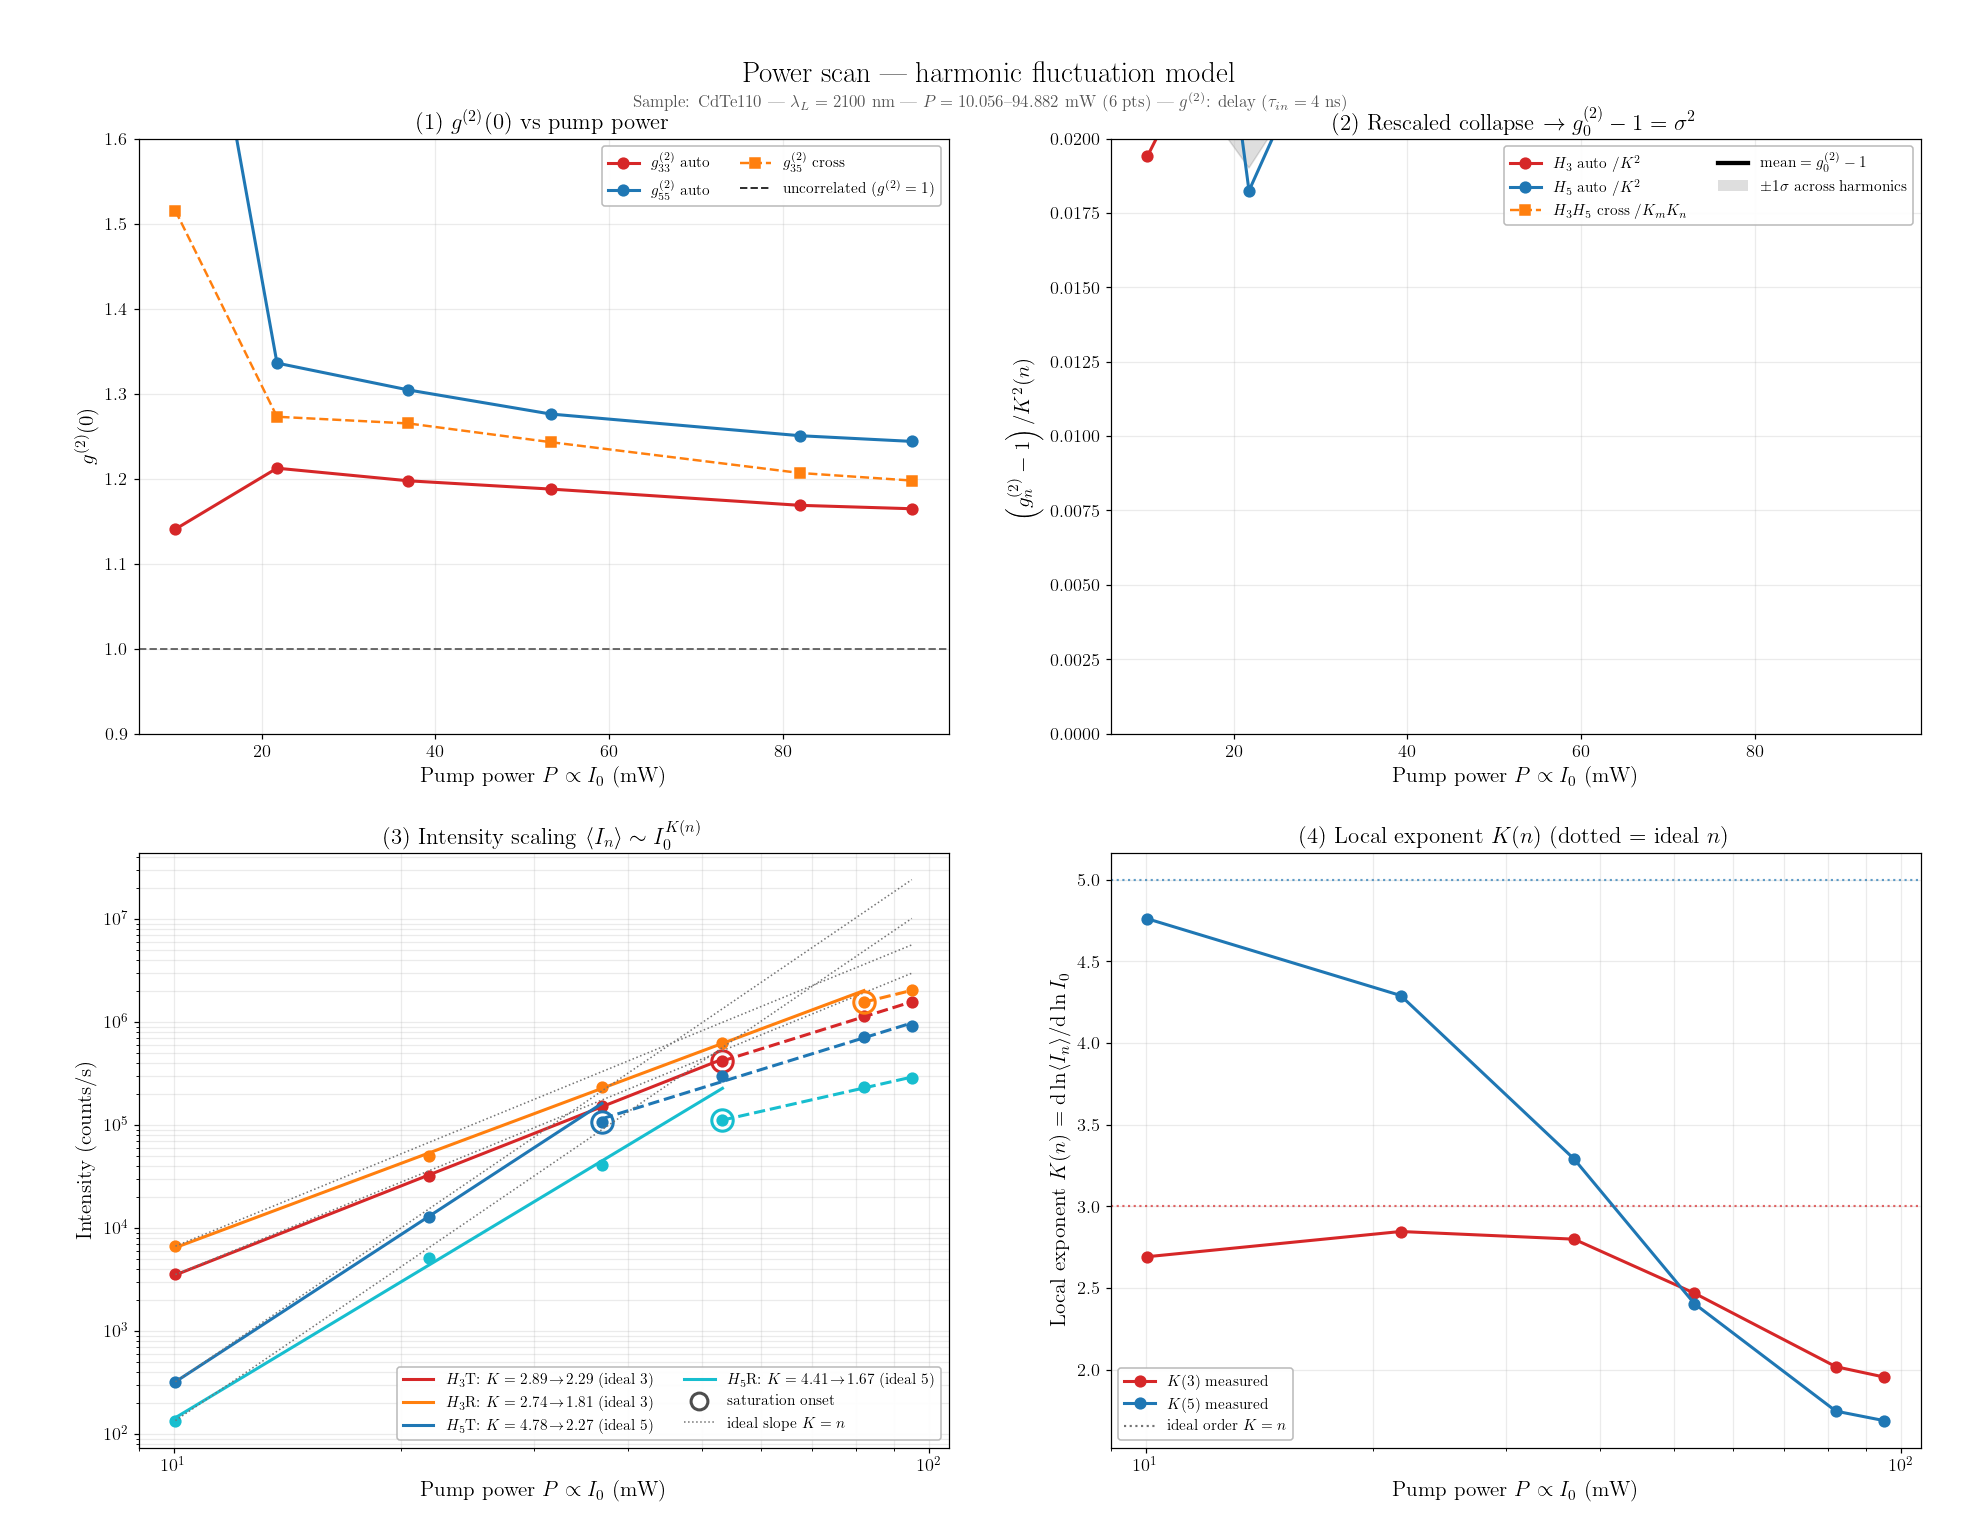

  model -> /Users/simon.wtmn/Desktop/Quantum_SHHG/results/2026-06-16/Jun23_powerscan_P1/model


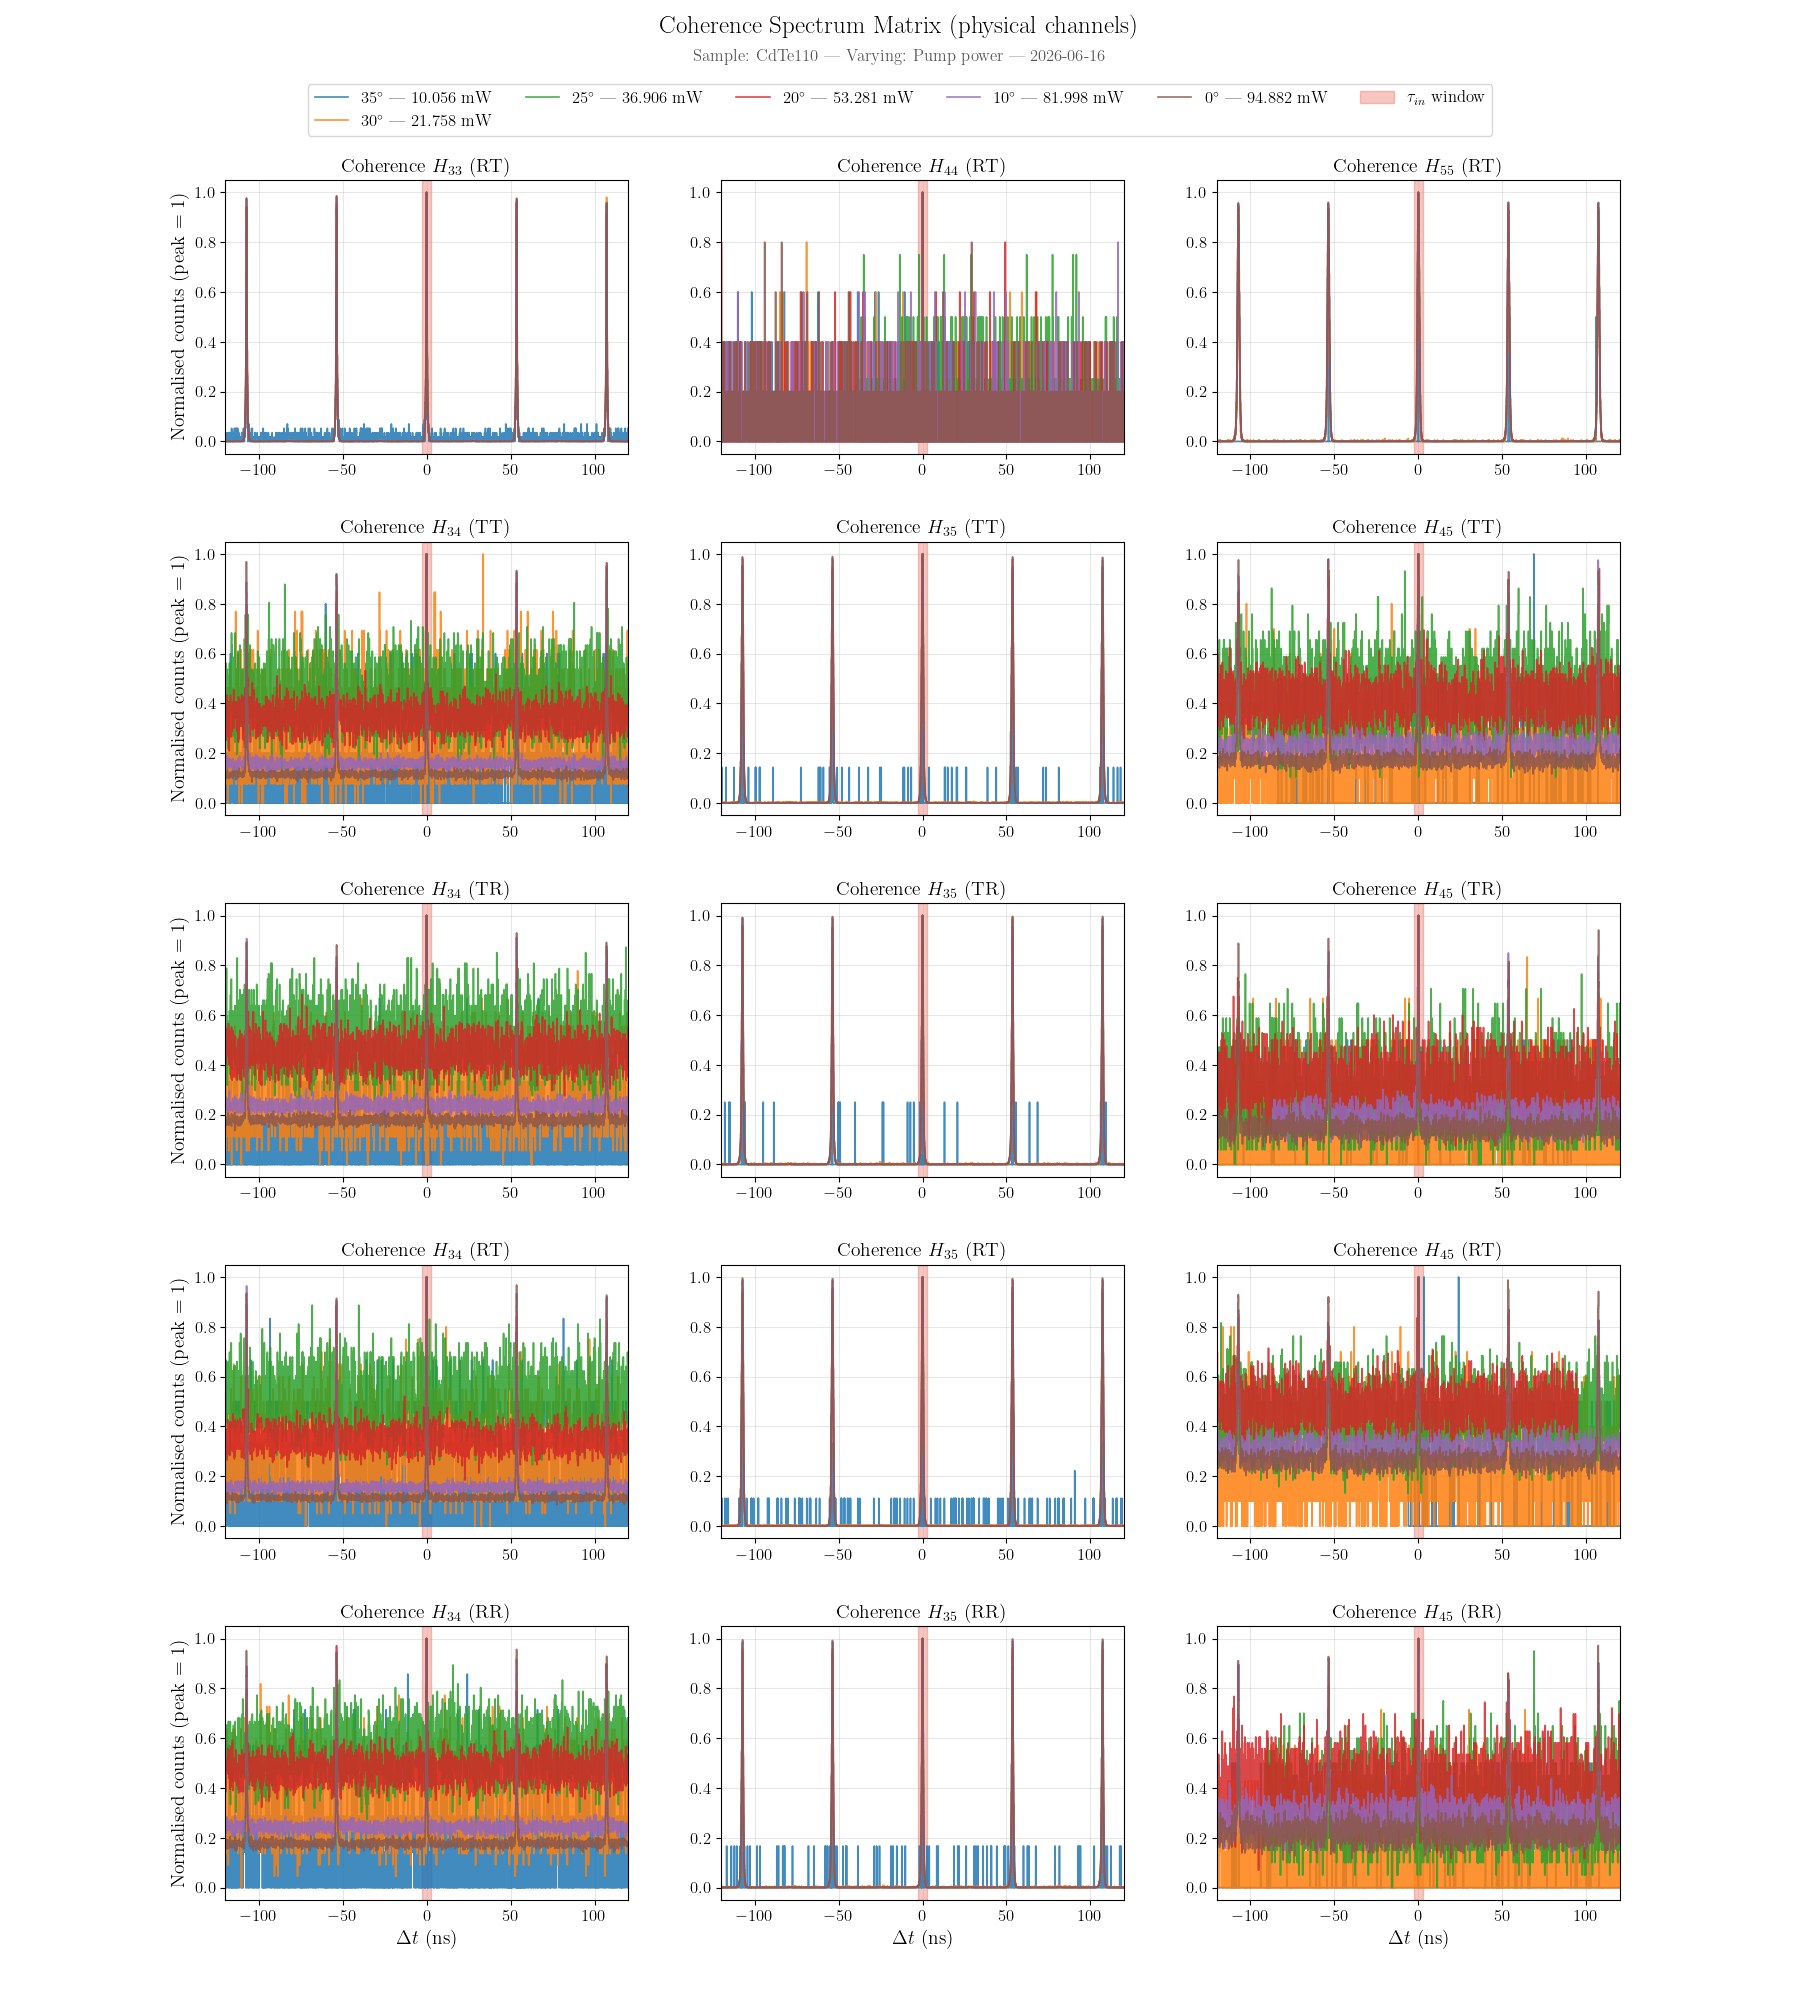

  coherence -> /Users/simon.wtmn/Desktop/Quantum_SHHG/results/2026-06-16/Jun23_powerscan_P1/coherence


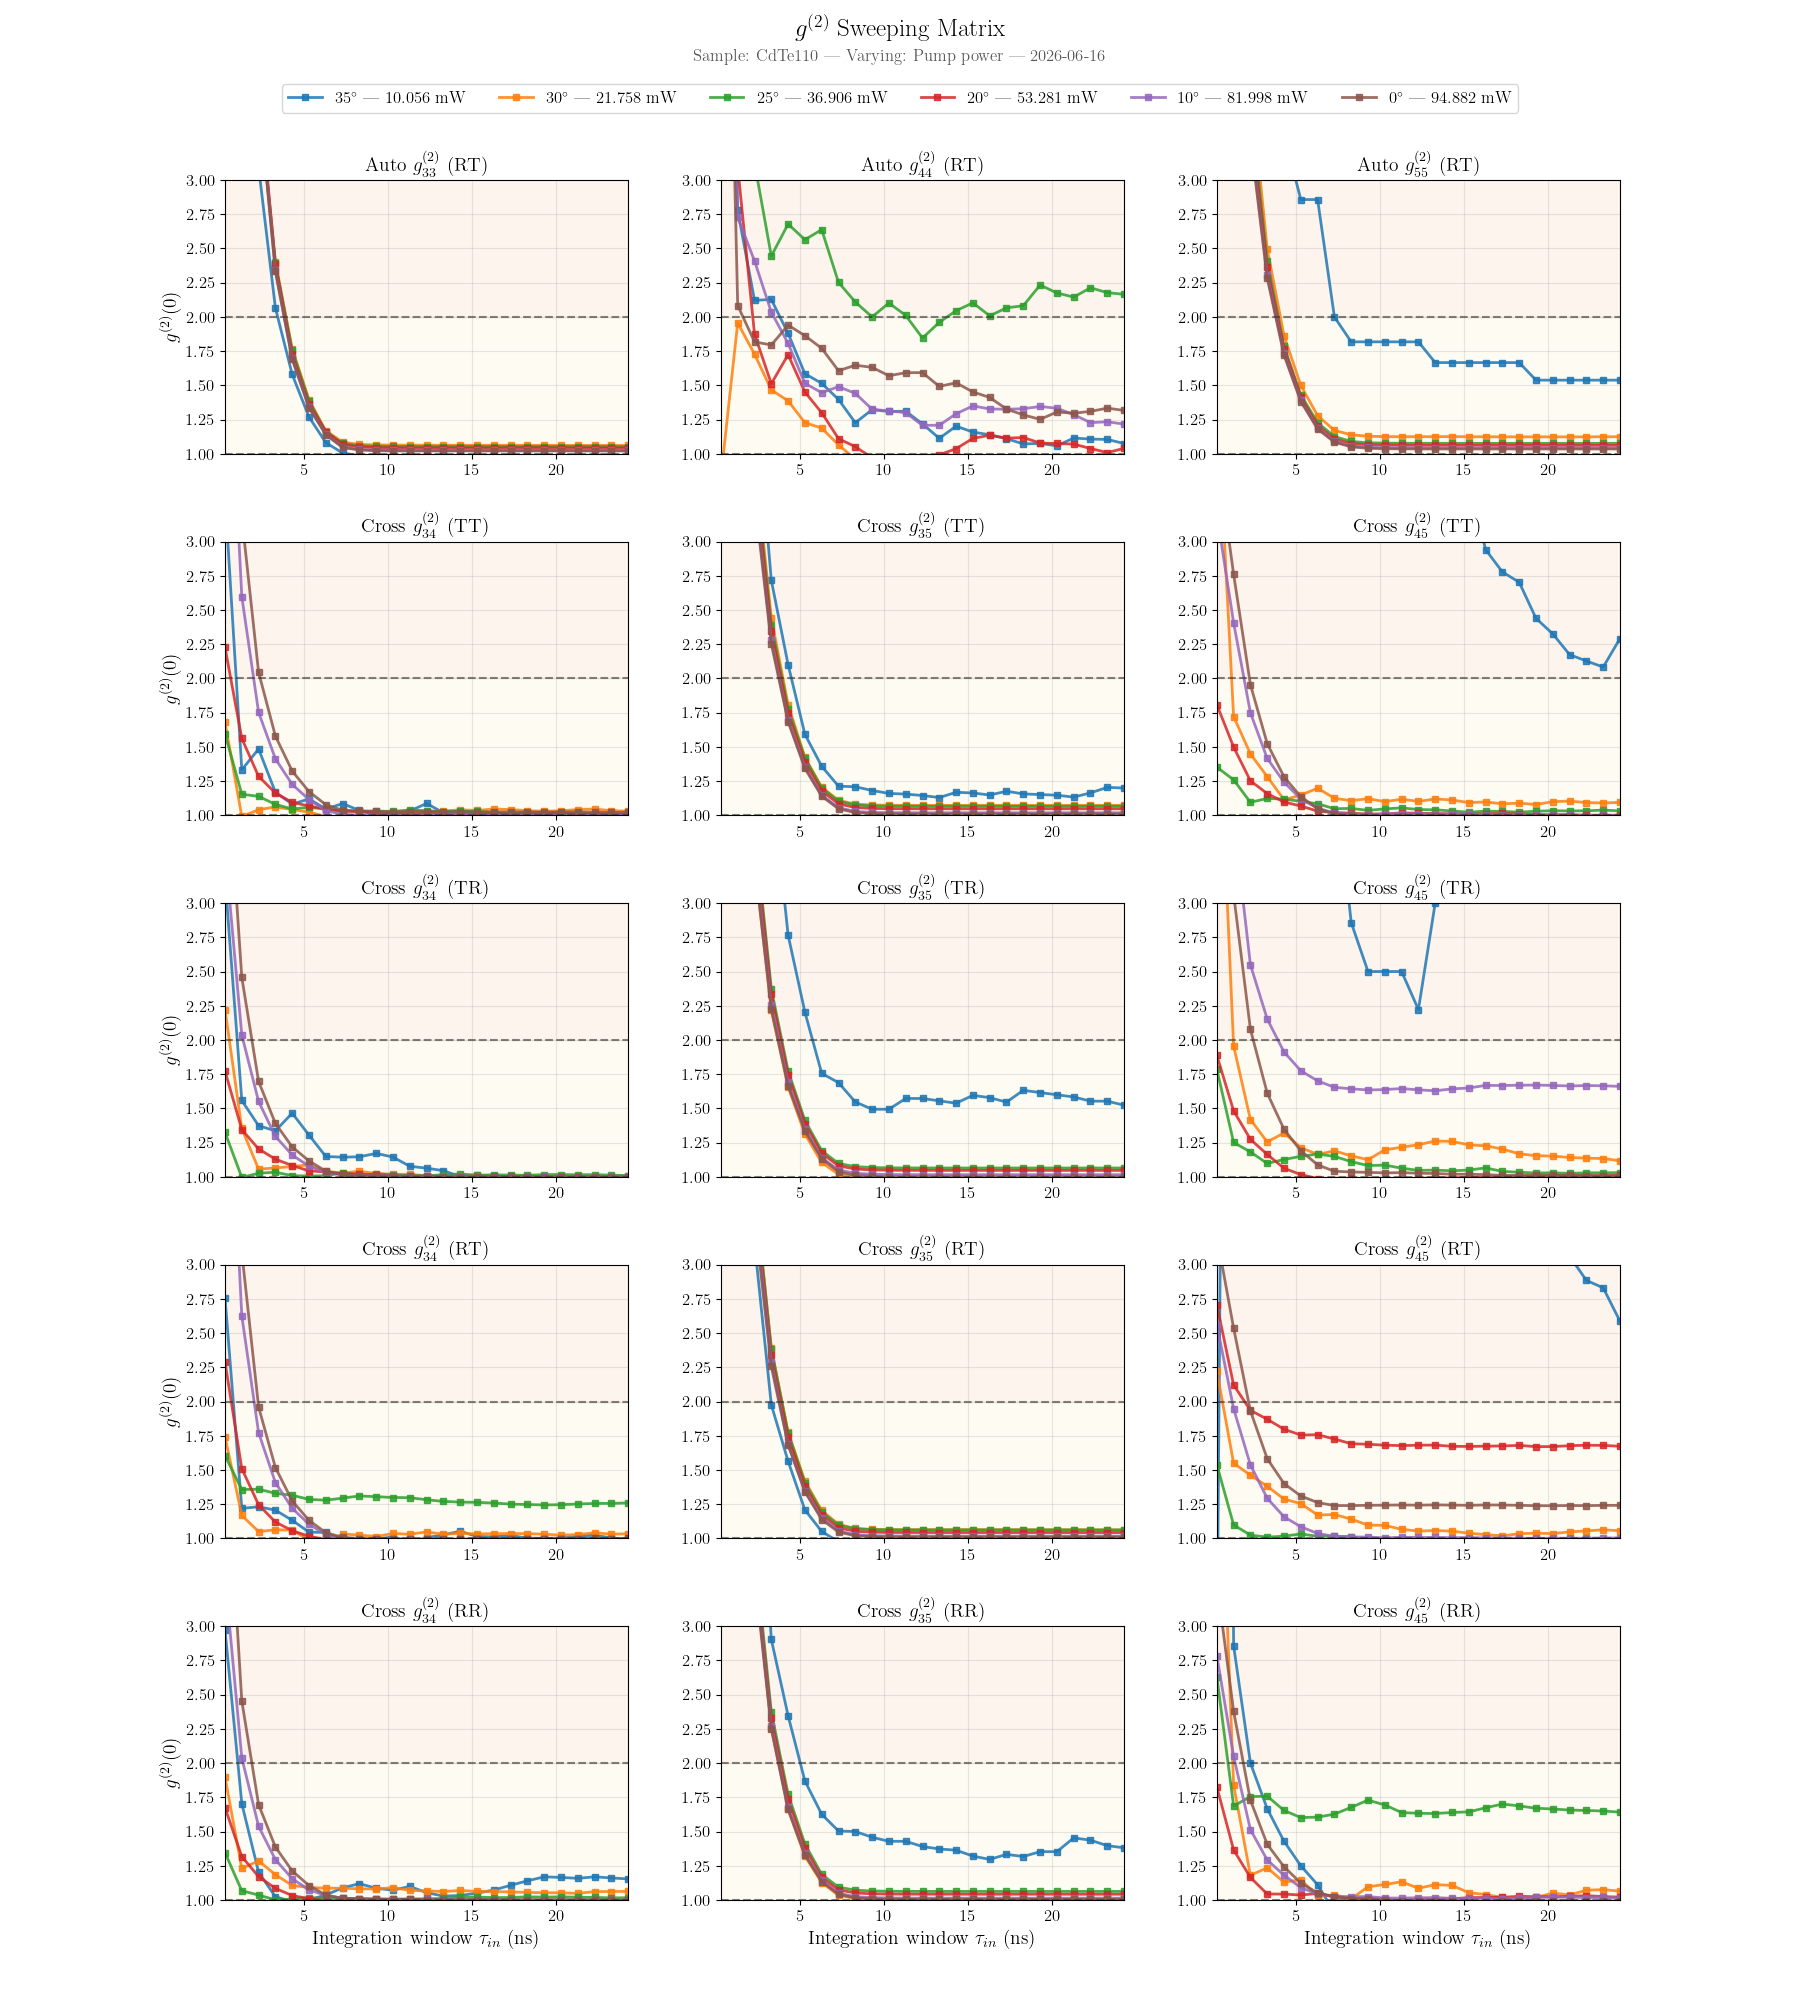

  g2        -> /Users/simon.wtmn/Desktop/Quantum_SHHG/results/2026-06-16/Jun23_powerscan_P1/g2


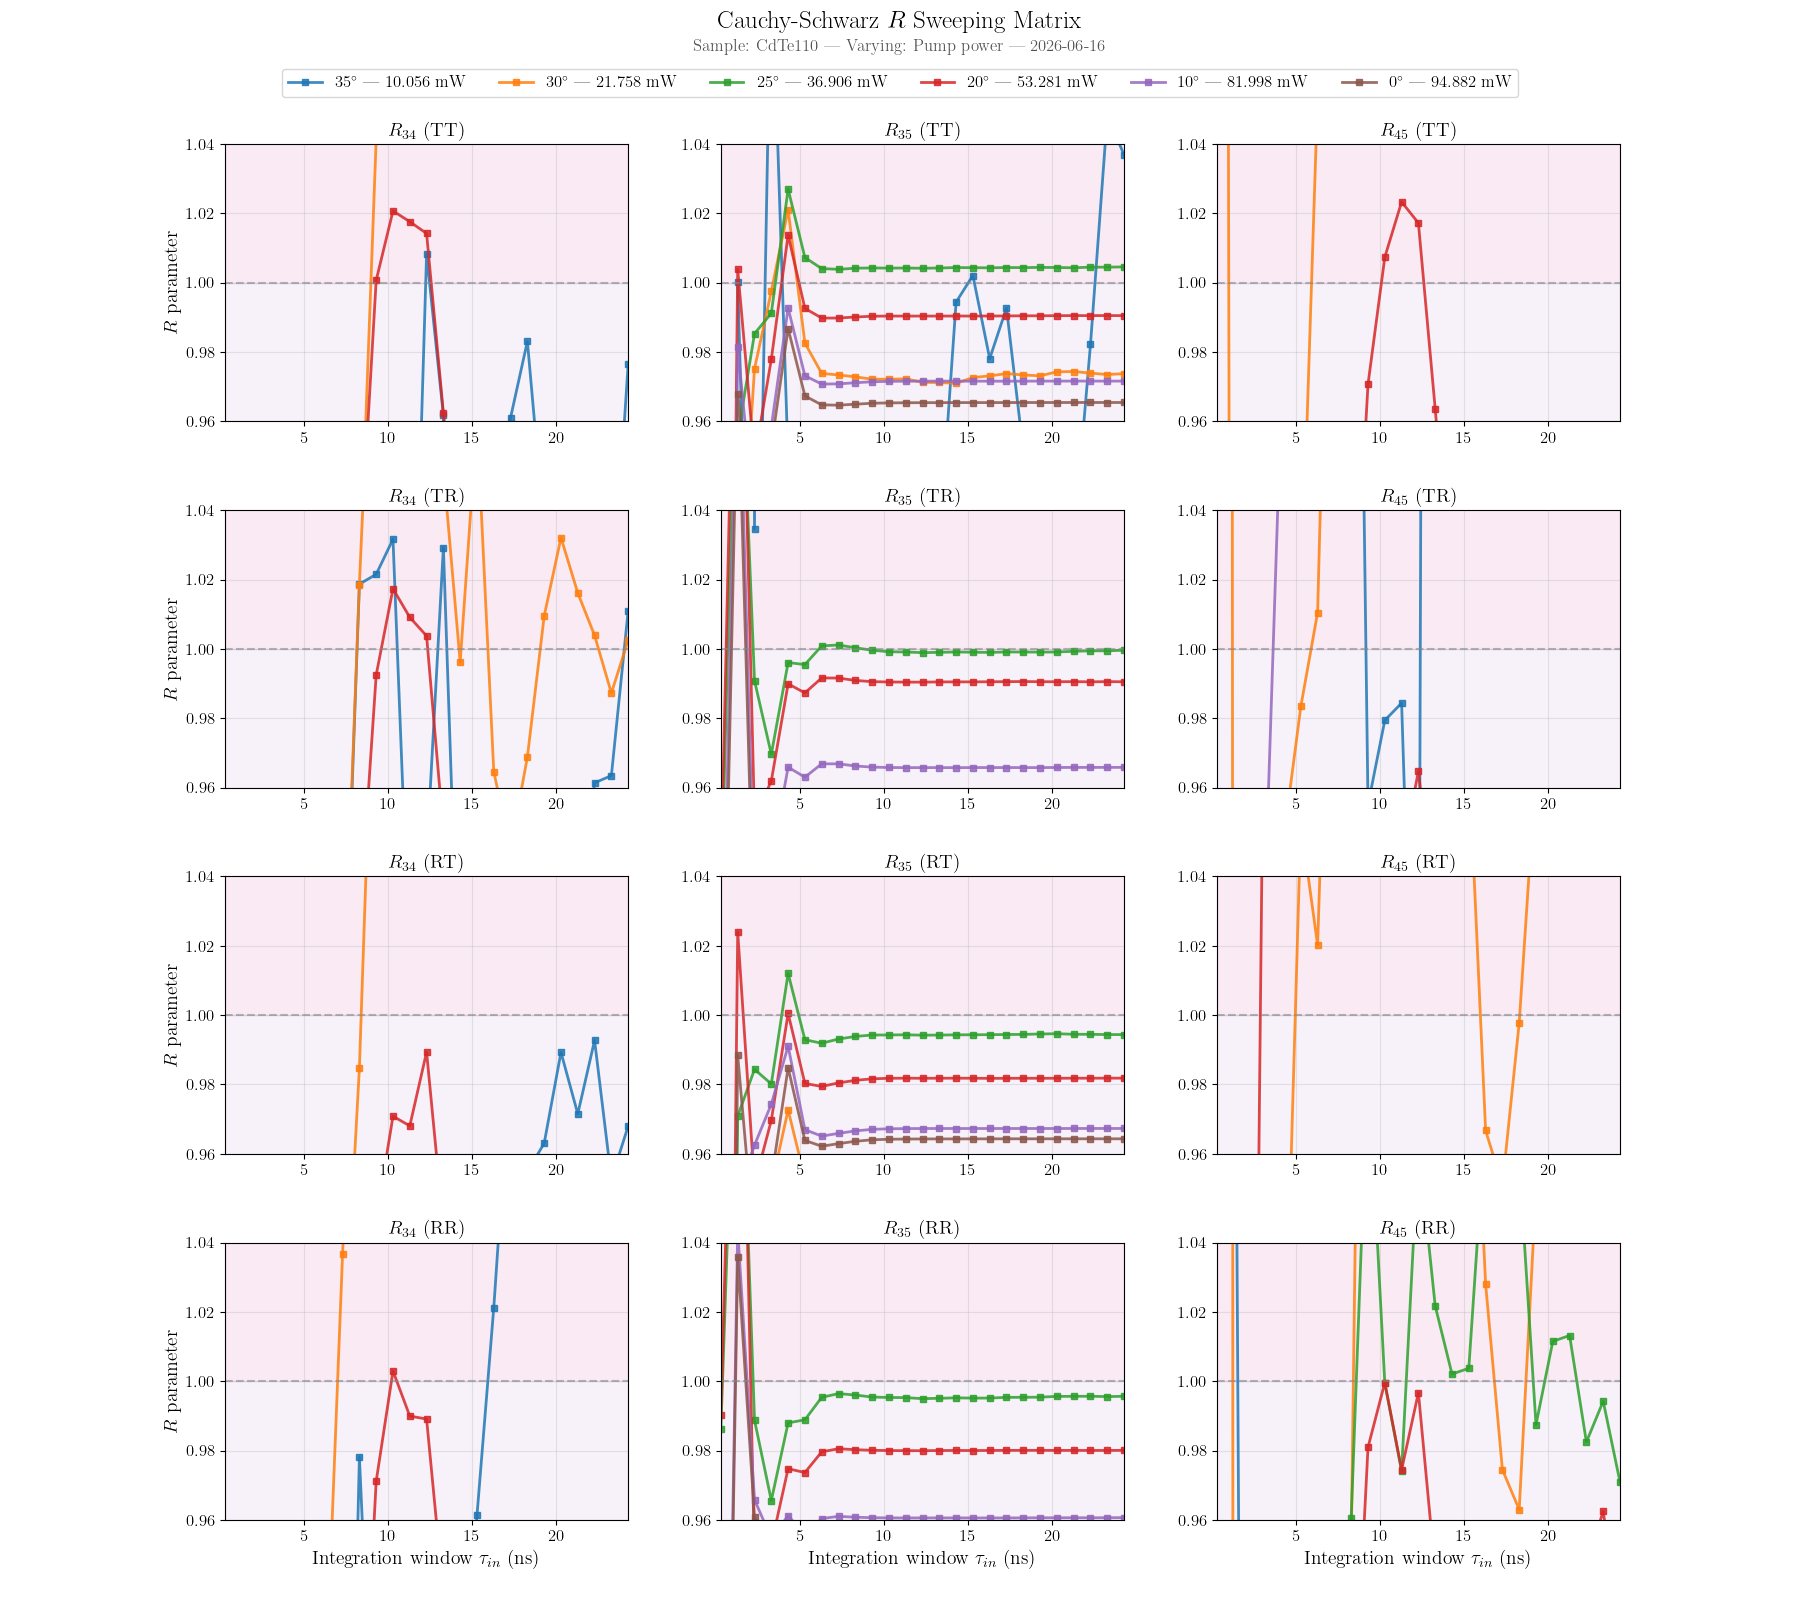

  R         -> /Users/simon.wtmn/Desktop/Quantum_SHHG/results/2026-06-16/Jun23_powerscan_P1/R


In [6]:
from src.report import PowerScanReport

rep = PowerScanReport(
    SCAN_PATH, title=TITLE, results_root=RESULTS_DIR,
    intensity_runs=DENSE_PATH, malus=MALUS,
    harmonics=HARMONICS, tau_in_ns=TAU_IN_NS, g2_method=G2_METHOD, k_poly_deg=K_POLY_DEG)

rep.summary()
rep.model(harmonics=HARMONICS, include_cross=True,
          g2_ylim=(0.9, 1.6), collapse_ylim=(0, 0.02), overview=True, show=True)

# correlation grids vs power (optional — comment out to skip)
rep.correlations(
    coherence=dict(xlim=120, integration_window_ns=5.0),
    g2=dict(methods=["delay"], tau_min=0.3, tau_max=25, step=1.0, num_side_peaks=5),
    R=dict(methods=["delay"], tau_min=0.3, tau_max=25, step=1.0, ylim=(0.96, 1.04)))

## 3. Quick zoom

Drag on any figure to zoom, or re-render one model plot with explicit `xlim` / `ylim`.

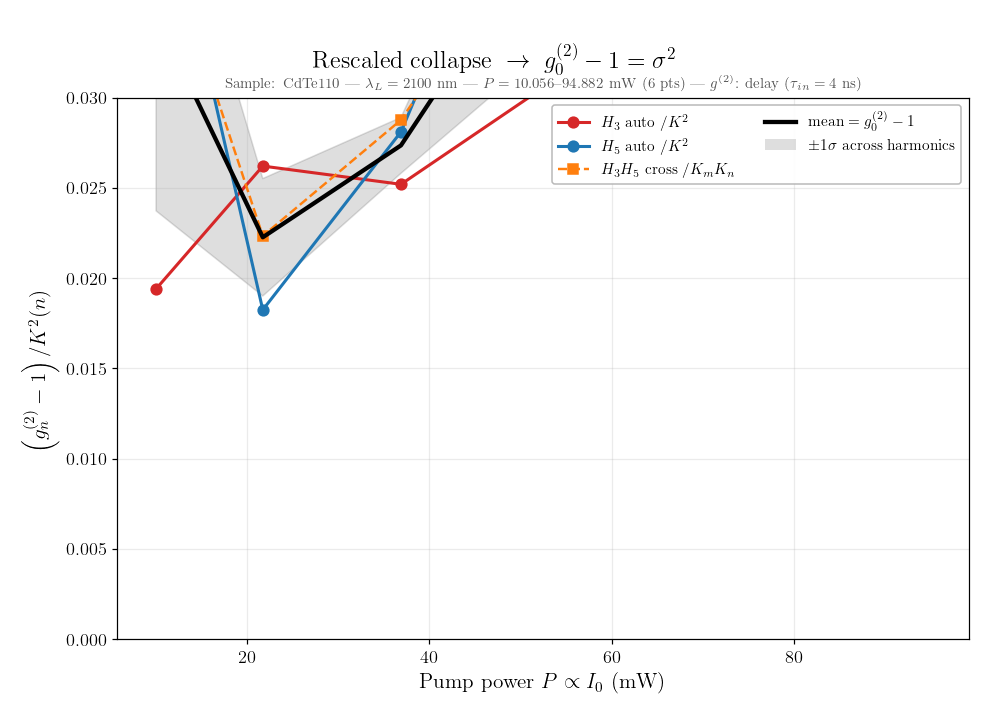

In [7]:
fig, ax = rep.analyzer.plot_g2_collapse(slope="local", harmonics=HARMONICS, include_cross=True, ylim=(0, 0.03))
rep._display(fig)